In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
r_u = 0
near_u = 0
smote = 2
scaler = 'minmax'
weight_multiplier = 1
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
features_to_remove = ['x', 'y', 'year']
#features_to_remove=[]


In [5]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv'

dataset = read_data(path)
dataset.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,6.229173,9.327499,7.851225,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.253413,0.164233,0.382909,-0.382909,0.243740,0.189907,0.401026,-0.401026,0.044376,0.051454,0.050562,0.050562,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.25,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,6.833876,9.632381,7.258680,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.331371,-0.125325,0.181410,-0.181410,0.328781,-0.127656,0.175605,-0.175605,0.053834,0.060592,0.055271,0.055271,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.51,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,7.183375,10.120540,4.959644,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.238927,-0.089832,0.144111,-0.144111,0.241070,-0.091286,0.144951,-0.144951,0.023444,0.040297,0.033327,0.033327,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.52,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,6.643856,9.787595,6.495086,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.257757,0.126741,0.363656,-0.363656,0.254301,0.126465,0.361181,-0.361181,0.039384,0.052719,0.050437,0.050437,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.34,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,6.992178,8.838208,9.737422,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.269825,0.101198,0.347946,-0.347946,0.258944,0.119827,0.353585,-0.353585,0.044928,0.065635,0.063431,0.063431,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.03,5025.2,5265.4,18910.088889,0


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 55 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           652 non-null    int64  
 1   NUTS2_ID       652 non-null    object 
 2   NUTS2_NAME     652 non-null    object 
 3   NUTS3_ID       652 non-null    object 
 4   NUTS3_NAME     652 non-null    object 
 5   x              652 non-null    float64
 6   y              652 non-null    float64
 7   min_temp_q1    652 non-null    float64
 8   mean_temp_q1   652 non-null    float64
 9   max_temp_q1    652 non-null    float64
 10  prec_q1        652 non-null    float64
 11  bio1           652 non-null    float64
 12  bio2           652 non-null    float64
 13  bio3           652 non-null    float64
 14  bio4           652 non-null    float64
 15  bio5           652 non-null    float64
 16  bio6           652 non-null    float64
 17  bio7           652 non-null    float64
 18  bio8      

In [7]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens', 'WNV_cases'],
      dtype='object')

In [8]:
print(f'Number of NUTS3 Units in {NUTS2}: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in CMacedonia: 7


In [9]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,2,31,33,5.06%
1,2012,3,20,23,3.53%
2,2013,3,21,24,3.68%
3,2014,7,0,7,1.07%
4,2015,7,0,7,1.07%
5,2016,7,0,7,1.07%
6,2017,7,0,7,1.07%
7,2018,0,117,117,17.94%
8,2019,0,53,53,8.13%
9,2020,0,93,93,14.26%


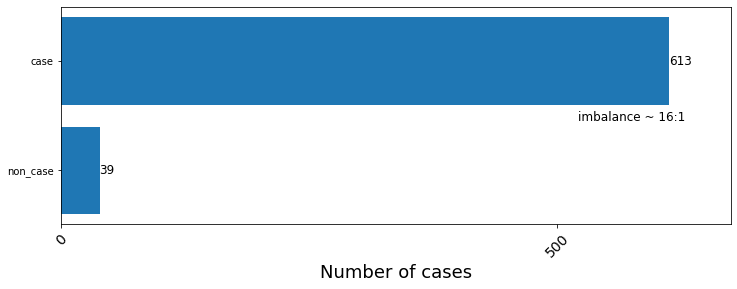

In [10]:
plot_imbalance(dataset, target_column='WNV_cases')

In [11]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] + features_to_remove).columns

In [12]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_train = data_train['WNV_cases']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'])
    y_test = data_test['WNV_cases']
    
    X_train, X_test, y_train, y_test, X_train_df, scaler, imputer = transform_data_new(X_train, X_test, y_train, y_test, r_u, near_u, smote, majority_class = 1, scaler_key=scaler, exclude_features=features_to_remove)
    w0,w1 = calculate_weights_new(y_train)
    w1 = w1*weight_multiplier

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model = train_lin_model(model, X_train, y_train)

    masker = shap.maskers.Independent(data = X_train)
    explainer = shap.LinearExplainer(trained_model, masker = masker)
    shap_values = explainer.shap_values(X_train)
    
    train, test, coef = predict_lin_model(trained_model, X_train_df, data_test, X_train, y_train, X_test, y_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

Fold: 0 || w0:6, w1:1 || ##
Fold: 1 || w0:6, w1:1 || ##
Fold: 2 || w0:6, w1:1 || ##
Fold: 3 || w0:6, w1:1 || ##
Fold: 4 || w0:6, w1:1 || ##
Fold: 5 || w0:6, w1:1 || ##
Fold: 6 || w0:6, w1:1 || ##
Fold: 7 || w0:6, w1:1 || ##
Fold: 8 || w0:6, w1:1 || ##
Fold: 9 || w0:6, w1:1 || ##


In [13]:
results_test.sort_values(by=['score'], ascending = False, ignore_index = True, inplace = True)

In [14]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,22.215876,40.552658,ημαθια,2022,1,0.999476
1,22.215876,40.552658,ημαθια,2022,1,0.999197
2,22.215876,40.552658,ημαθια,2022,1,0.999129
3,22.215876,40.552658,ημαθια,2022,1,0.999045
4,22.215876,40.552658,ημαθια,2022,1,0.998983
...,...,...,...,...,...,...
282,22.109199,40.888821,πελλα,2015,0,0.003176
283,22.215876,40.552658,ημαθια,2015,0,0.002194
284,22.758634,41.016242,κιλκις,2015,0,0.001700
285,22.441443,40.269748,πιερια,2015,0,0.001376


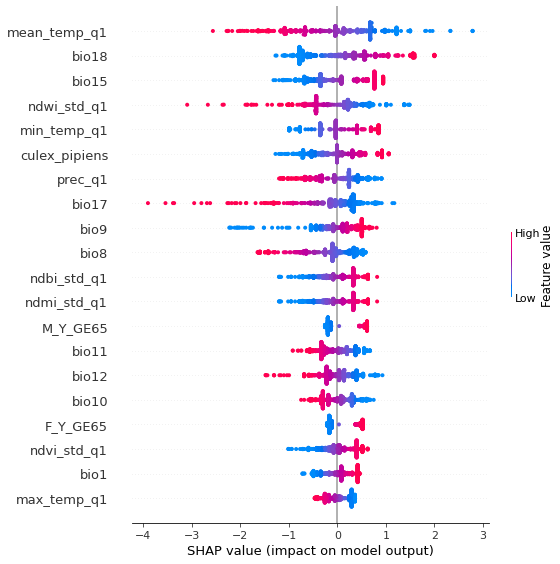

In [15]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names)

In [16]:
shap_values.shape

(657, 47)

In [17]:
feature_names.shape

(47,)

In [18]:
X_train.shape

(657, 47)

In [19]:
mean_shap_values = shap_values.mean(axis=0)

In [20]:
mean_shap_values.shape

(47,)

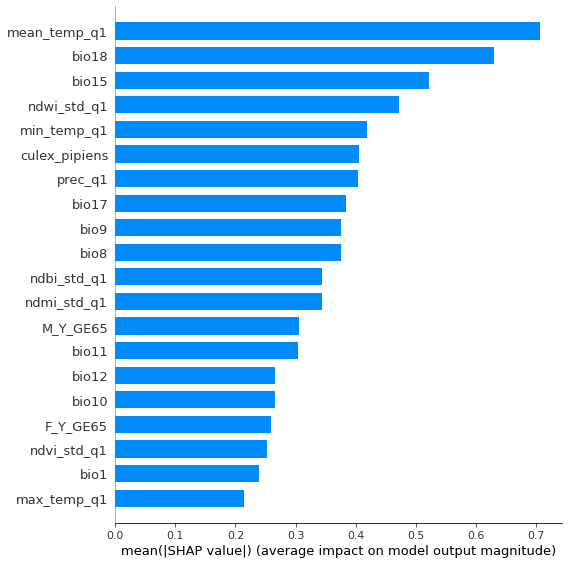

In [21]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar')

In [22]:
mean_shap_values = shap_values.mean(axis=0)

ft_importance = pd.DataFrame()

for i in range(len(feature_names)):
    ft_importance = ft_importance.append({'Feature': feature_names[i],
                                          'Shap': mean_shap_values[i]}, ignore_index = True)

ft_importance.sort_values(by='Shap', key=pd.Series.abs, inplace = True, ascending = False)

ft_importance

,Feature,Shap
11,bio8,-0.107105
46,culex_pipiens,-0.045317
38,M_Y_GE65,0.036792
0,min_temp_q1,0.031709
21,bio18,0.031316
42,F_Y_GE65,0.030911
12,bio9,0.030559
3,prec_q1,-0.027629
14,bio11,-0.027438
9,bio6,-0.025537


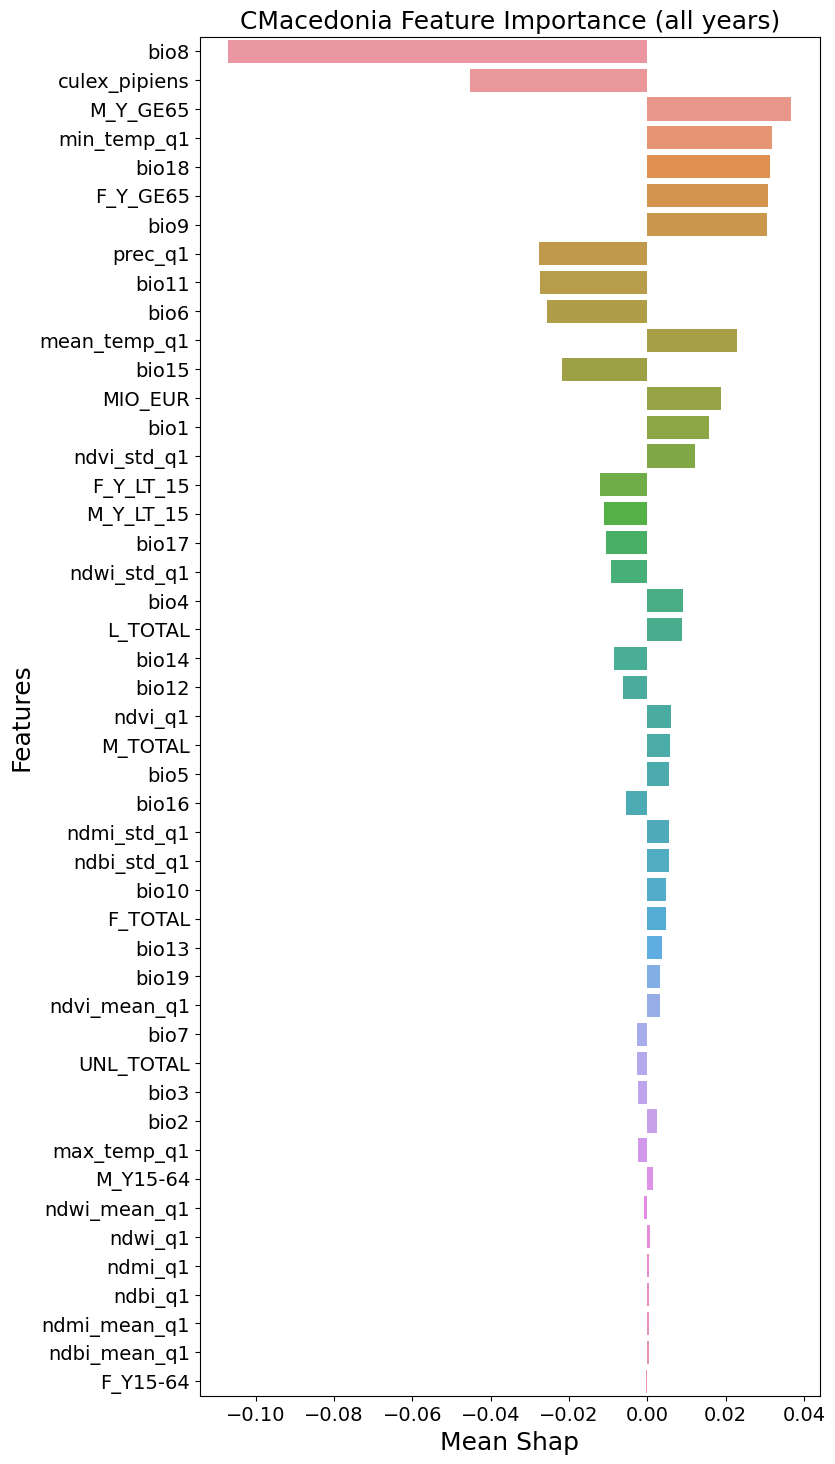

In [23]:
mean_shap = ft_importance['Shap']
shp = mean_shap.shape[0]
mean_shap = mean_shap.to_numpy().reshape(1,shp)

plot_feature_importance(mean_shap, ft_importance['Feature'], x_label = 'Mean Shap', title = f'{NUTS2} Feature Importance (all years)', title_size=18)

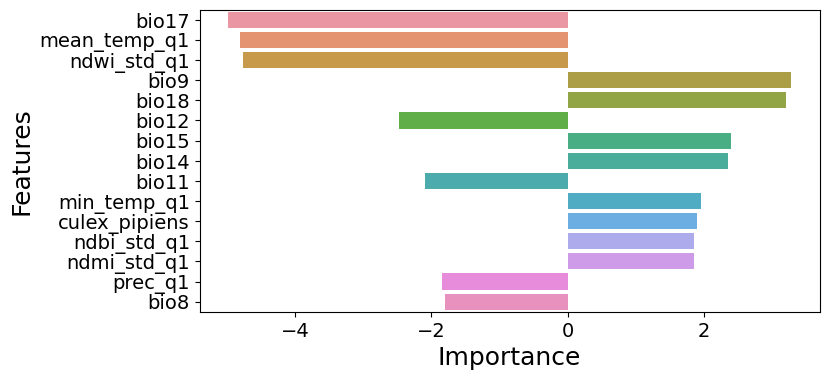

In [24]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

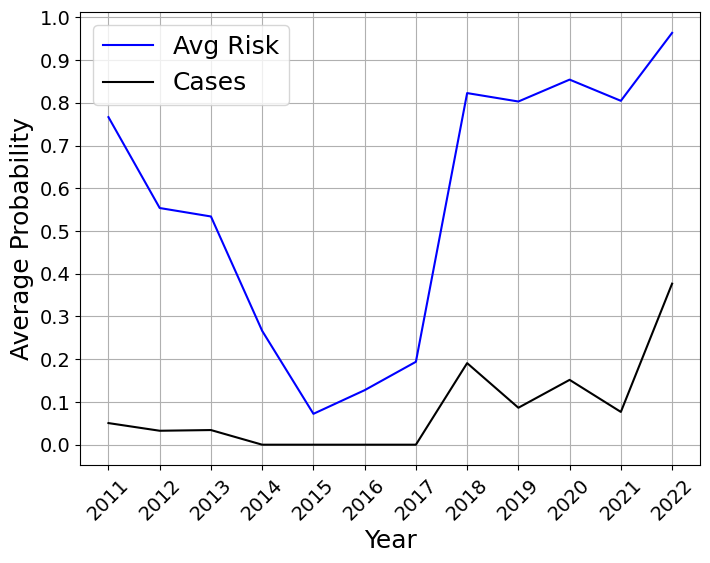

In [25]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

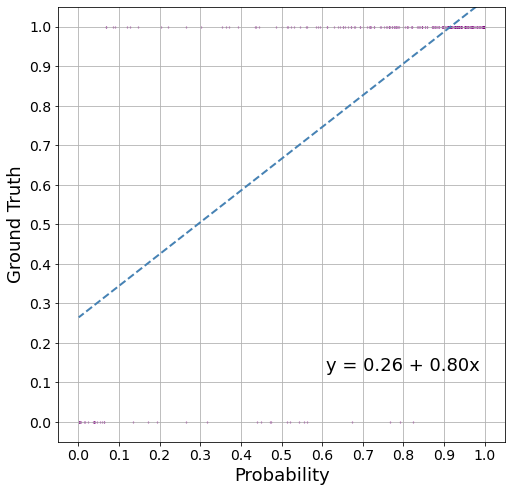

In [26]:
plot_probability_curve(results_test)

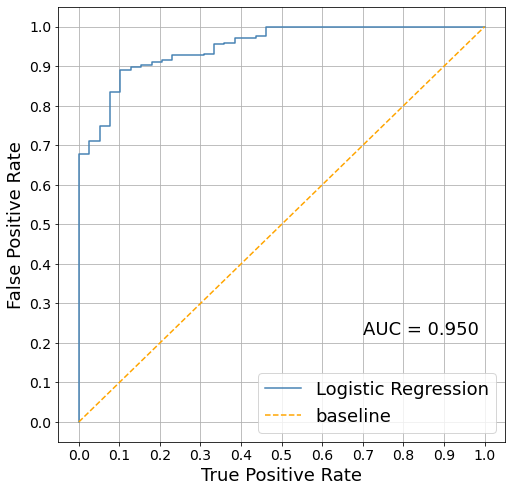

In [27]:
plot_roc_curve(results_test)

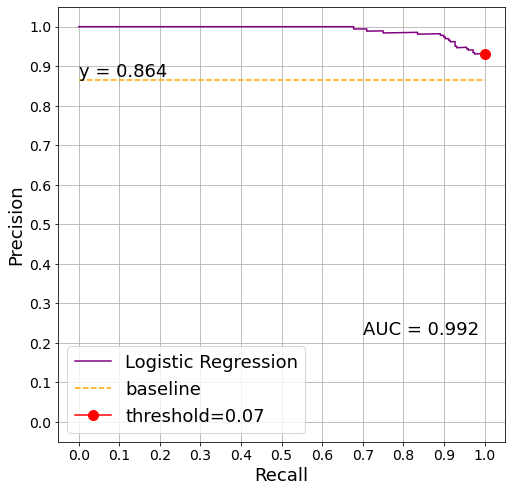

In [28]:
plot_pr_curve(results_test, plot_fbeta=True)

In [29]:
results_test

,x,y,NUTS3_NAME,year,case,score
0,22.215876,40.552658,ημαθια,2022,1,0.999476
1,22.215876,40.552658,ημαθια,2022,1,0.999197
2,22.215876,40.552658,ημαθια,2022,1,0.999129
3,22.215876,40.552658,ημαθια,2022,1,0.999045
4,22.215876,40.552658,ημαθια,2022,1,0.998983
...,...,...,...,...,...,...
282,22.109199,40.888821,πελλα,2015,0,0.003176
283,22.215876,40.552658,ημαθια,2015,0,0.002194
284,22.758634,41.016242,κιλκις,2015,0,0.001700
285,22.441443,40.269748,πιερια,2015,0,0.001376


In [30]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [31]:
results_test

,x,y,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,22.215876,40.552658,ημαθια,2022,1,0.999476,1,1,1
1,22.215876,40.552658,ημαθια,2022,1,0.999197,1,1,1
2,22.215876,40.552658,ημαθια,2022,1,0.999129,1,1,1
3,22.215876,40.552658,ημαθια,2022,1,0.999045,1,1,1
4,22.215876,40.552658,ημαθια,2022,1,0.998983,1,1,1
...,...,...,...,...,...,...,...,...,...
282,22.109199,40.888821,πελλα,2015,0,0.003176,0,0,0
283,22.215876,40.552658,ημαθια,2015,0,0.002194,0,0,0
284,22.758634,41.016242,κιλκις,2015,0,0.001700,0,0,0
285,22.441443,40.269748,πιερια,2015,0,0.001376,0,0,0


In [32]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
#log_loss_test_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [33]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
#log_loss_test_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [34]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
#log_loss_test_03 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [35]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05}

In [36]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [37]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall
Threshold: 0.1,0.923345,0.761166,0.956863,0.931298,0.983871
Threshold: 0.2,0.923345,0.793579,0.956349,0.941406,0.971774
Threshold: 0.5,0.902439,0.846309,0.942387,0.962185,0.923387
